# 1 - Descarga y exploración del corpus (EDA)

El alumno descargará el/los corpus que desee (detalle sobre los datos a utilizar en
el siguiente punto) y realizará un análisis exploratorio de los datos.
Este ejercicio deberá contener:

- Cardinalidad del vocabulario
- Distribución de reviews por número de estrellas
- No de reviews positivas y negativas
- N-grams más frecuentes
- Nubes de palabras
- Visualización en 2 dimensiones de algunos word embeddings calculados con
Word2Vec (elegir 4-5 palabras y pintar las top 10 más similares)
- Conclusiones de la exploración
- Cualquier otra métrica / exploración / cálculo que el alumno considere

## Datasets
Reviews de Amazon: Reviews de productos de Amazon clasificadas por categorías (libros,
electrónica, automoción, ...). Las reviews contienen la calificación (número de estrellas) por
lo que es perfecto para problemas de clasificación supervisada del sentimiento.
El alumno deberá escoger el dataset que desee (puede trabajar con varios si así lo
prefiere) de los que aparecen en la columna “5-core”. Se recomienda trabajar con
subsets de dichos datasets para evitar problemas de memoria.
Enlace: https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html

In [45]:
# Montar Google Drive (si ejecutamos en Google Colab) y definir directorio de datos
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = '/content/drive/MyDrive/NLP/Practica/'
except ImportError:
    data_dir = './'

# Nos aseguramos de que el directorio exista
os.makedirs(data_dir, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


El dataset elegido es _Musical Instruments_ con las siguientes características:

    reviewerID - ID of the reviewer, e.g. A2SUAM1J3GNN3B
    asin - ID of the product, e.g. 0000013714
    reviewerName - name of the reviewer
    helpful - helpfulness rating of the review, e.g. 2/3
    reviewText - text of the review
    overall - rating of the product
    summary - summary of the review
    unixReviewTime - time of the review (unix time)
    reviewTime - time of the review (raw)

In [46]:
#Cargamos el dataset
import pandas as pd
import gzip
import urllib.request

df_link = 'https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Musical_Instruments_5.json.gz'
gzFile = 'reviews_Musical_Instruments_5.json.gz'


def download_df(link, toFile):
  urllib.request.urlretrieve(link, toFile)

def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield eval(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')


#--------------------------
download_df(df_link, gzFile)
df = getDF('./' + gzFile )
df.to_csv('df_file.csv')

In [47]:
# función para mostrar texto en negrita
def bold(text):
    return f"\033[1m{text}\033[0m"

In [48]:
df.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      10261 non-null  object 
 1   asin            10261 non-null  object 
 2   reviewerName    10234 non-null  object 
 3   helpful         10261 non-null  object 
 4   reviewText      10261 non-null  object 
 5   overall         10261 non-null  float64
 6   summary         10261 non-null  object 
 7   unixReviewTime  10261 non-null  int64  
 8   reviewTime      10261 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.0+ MB


El dataset no contiene nulos en los campos interesados: reviewText, overall

In [50]:
df.shape

(10261, 9)

In [51]:
#longitud máxima reseña (review)
import numpy as np
import re

rec_max = np.max(df['reviewText'].str.len().argmax())

num_words = 0
list_of_words_rw = []
x_re = ''

for x in df['reviewText'].tolist():
  matches = re.findall('[a-zA-Z0-9 ]*', x)

  len_x = len(matches)

  list_of_words_rw.append(len_x) # list with size of every line
  num_words = max(num_words, len_x) # max num of words per line


# Calculate the median number of words in each line.
median_words_rw = np.median(list_of_words_rw)


corpus = ''
total_words = 0

for x in df['reviewText'].tolist():
  matches = re.findall('[a-zA-Z0-9 ]*', x)
  corpus += ''.join(matches)
  total_words += len(x.split())




In [52]:
print(bold('Max record length          :')+ ' {:>6}'.format(rec_max))
print(bold('Max length words review    :')+ ' {:>6}'.format(num_words))
print(bold('Mean length words review   :')+' {:>6.2f}'.format(median_words_rw))
print(bold('Palabras totales reviewText:'), total_words)


Max record length          :   6576
Max length words review    :    817
Mean length words review   :  17.00
Palabras totales reviewText: 925371


En esta sección obtengo los totales por score (overall) que me servirá para contrastar con el análisis de sentimiento.

In [53]:
ovrall = ovrall = df.groupby('overall')['overall'].count()

print(ovrall.index.values)
print(ovrall.array)

[1. 2. 3. 4. 5.]
<NumpyExtensionArray>
[np.int64(217), np.int64(250), np.int64(772), np.int64(2084), np.int64(6938)]
Length: 5, dtype: int64


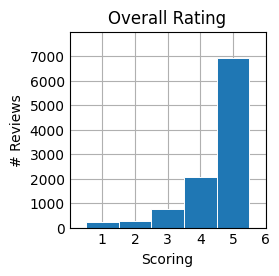

In [54]:
# Distribución de reviews por número de estrellas
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = ovrall.index.values
y = ovrall.array

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(autoscale_on=True,
       xlim=(0,5), xticks=np.arange(1, 7),
       ylim=(0, 8000), yticks=np.arange(0, 8000, 1000))

ax.set_xlabel('Scoring')
ax.set_ylabel('# Reviews')
ax.set_title('Overall Rating')

plt.show()

In [55]:
from collections import Counter

In [56]:
words_nltk = corpus.lower().split()

In [57]:
words_nltk[:10]

['not', 'much', 'to', 'write', 'about', 'here', 'but', 'it', 'does', 'exactly']

In [58]:
wf = Counter(words_nltk)
wf_most_common = wf.most_common(10)
wf_most_common

[('the', 43540),
 ('a', 27752),
 ('and', 26862),
 ('i', 23732),
 ('to', 22967),
 ('it', 19799),
 ('is', 14554),
 ('of', 13579),
 ('for', 12984),
 ('this', 11223)]

In [59]:
# N-gramas
from nltk import ngrams
from nltk.probability import FreqDist

In [60]:
bigrams_ = list(ngrams(words_nltk, 2))
trigrams_ = list(ngrams(words_nltk, 3))

In [61]:
bigrams_[:10]

[('not', 'much'),
 ('much', 'to'),
 ('to', 'write'),
 ('write', 'about'),
 ('about', 'here'),
 ('here', 'but'),
 ('but', 'it'),
 ('it', 'does'),
 ('does', 'exactly'),
 ('exactly', 'what')]

In [62]:
trigrams_[:10]

[('not', 'much', 'to'),
 ('much', 'to', 'write'),
 ('to', 'write', 'about'),
 ('write', 'about', 'here'),
 ('about', 'here', 'but'),
 ('here', 'but', 'it'),
 ('but', 'it', 'does'),
 ('it', 'does', 'exactly'),
 ('does', 'exactly', 'what'),
 ('exactly', 'what', 'its')]

In [63]:
# Wordcloud
from wordcloud import WordCloud
def plot_word_cloud(corpus):
    wordcloud = WordCloud(max_font_size=50, max_words=50, background_color="white").generate(' '.join(corpus))
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

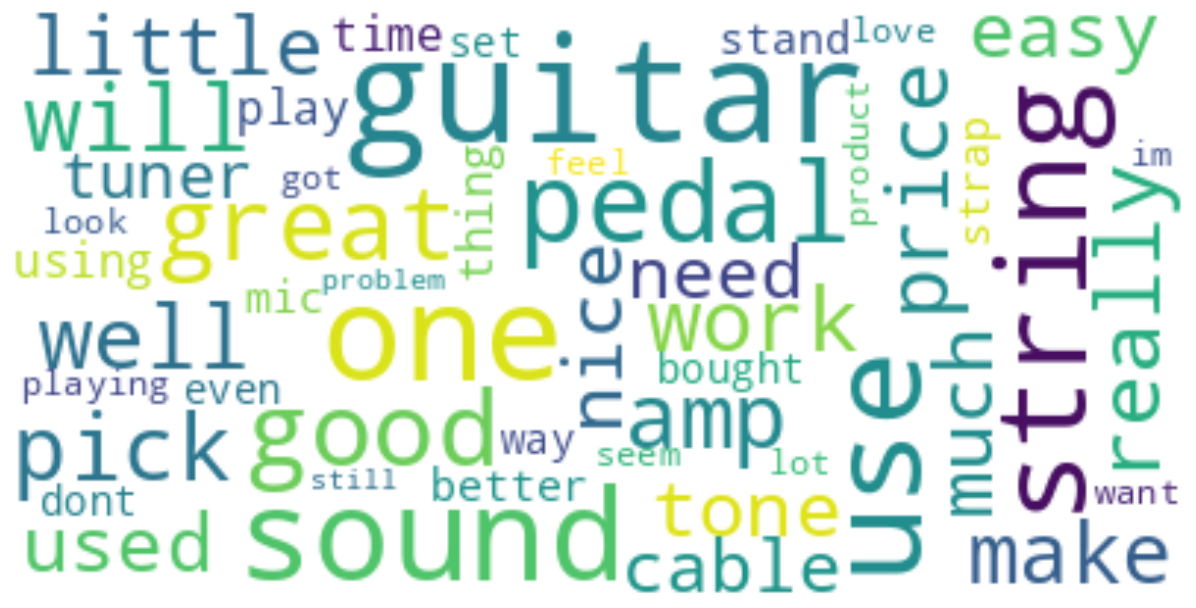

In [64]:
words_list = corpus.lower().strip().split()
plot_word_cloud(words_list)

In [65]:
# Guardamos el dataset original y variables necesarias para el siguiente notebook
import pickle
with open(os.path.join(data_dir, 'df_eda.pkl'), 'wb') as f:
    pickle.dump((df, median_words_rw), f)
